# Fairness Robustness in Sequential Learning and Dynamic Learning Environments

## Research Overview

This study investigates how fairness performance evolves during sequential model updates and dynamic deployment conditions.

Unlike traditional fairness evaluation approaches that assess fairness only once during model training, this research examines fairness robustness over time as machine learning models encounter changing data distributions and repeated updates.

The study evaluates:

- Model Accuracy
- Fairness Difference
- Fairness Drift
- Sequential Learning Robustness
- Distribution Shift Effects

Protected Attribute:
Sex

Dataset:
Adult Census Income Dataset

In [6]:
# =====================================================
# IMPORT REQUIRED LIBRARIES
# =====================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

## Load Adult Census Dataset

The Adult Income dataset is used to investigate fairness differences across demographic groups.

The target variable predicts whether an individual's income exceeds $50,000 per year.

In [5]:
# =====================================================
# LOAD DATASET
# =====================================================

df = pd.read_csv("../datasets/adult.csv")

print("Dataset Loaded Successfully")
print()

print(df.head())

Dataset Loaded Successfully

   age workclass  fnlwgt     education  education.num marital.status  \
0   90         ?   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66         ?  186061  Some-college             10        Widowed   
3   54   Private  140359       7th-8th              4       Divorced   
4   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  capital.gain  \
0                  ?  Not-in-family  White  Female             0   
1    Exec-managerial  Not-in-family  White  Female             0   
2                  ?      Unmarried  Black  Female             0   
3  Machine-op-inspct      Unmarried  White  Female             0   
4     Prof-specialty      Own-child  White  Female             0   

   capital.loss  hours.per.week native.country income  
0          4356              40  United-States  <=50K  
1          4356  

## Dataset Inspection

This section examines:

- Number of records
- Number of variables
- Missing values

In [7]:
# =====================================================
# DATASET SHAPE
# =====================================================

print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(32561, 15)


In [8]:
# =====================================================
# COLUMN NAMES
# =====================================================

print(df.columns)

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')


In [9]:
# =====================================================
# CHECK MISSING VALUES
# =====================================================

print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


## Data Preprocessing

The target variable is converted into binary format:

0 = Income ≤ 50K

1 = Income > 50K

In [10]:
# =====================================================
# ENCODE TARGET VARIABLE
# =====================================================

df["income"] = df["income"].apply(
    lambda x: 1 if x == ">50K" else 0
)

print(df["income"].value_counts())

income
0    24720
1     7841
Name: count, dtype: int64


## Encode Categorical Variables

Machine learning algorithms require numerical inputs.

Categorical variables are therefore converted into numerical representations.

# =====================================================
# LABEL ENCODING
# =====================================================

encoder = LabelEncoder()

categorical_columns = [
    'workclass',
    'education',
    'marital.status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native.country'
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

print(df.head())

## Feature Selection

Features represent the predictor variables used for training.

The protected attribute used for fairness evaluation is:

Sex

In [12]:
# =====================================================
# FEATURE SELECTION
# =====================================================

X = df.drop("income", axis=1)

y = df["income"]

protected_attribute = df["sex"]

print(X.shape)

(32561, 14)


# Sequential Learning Simulation

This section simulates continual model updates.

Instead of training only once, the model is repeatedly updated using additional data batches.

This enables investigation of fairness robustness under sequential learning conditions.

In [13]:
# =====================================================
# CREATE SEQUENTIAL BATCHES
# =====================================================

batch_size = len(df) // 4

print("Batch Size:", batch_size)

Batch Size: 8140


# Sequential Model Training and Fairness Evaluation

This section simulates sequential learning by gradually introducing new data batches into the training process.

At each update:

1. The model is retrained.
2. Accuracy is measured.
3. Fairness Difference is measured.
4. Fairness robustness is evaluated.

This allows observation of fairness drift during continual learning.

In [14]:
# =====================================================
# CREATE SEQUENTIAL DATA BATCHES
# =====================================================

batch1 = df.iloc[:batch_size]

batch2 = df.iloc[batch_size:2*batch_size]

batch3 = df.iloc[2*batch_size:3*batch_size]

batch4 = df.iloc[3*batch_size:]

print("Batch 1:", batch1.shape)
print("Batch 2:", batch2.shape)
print("Batch 3:", batch3.shape)
print("Batch 4:", batch4.shape)

Batch 1: (8140, 15)
Batch 2: (8140, 15)
Batch 3: (8140, 15)
Batch 4: (8141, 15)


# Sequential Fairness Evaluation Setup

Lists are created to store:

- Accuracy Scores
- Fairness Differences
- Sequential Update Labels

These results will later be visualised to identify fairness drift.

In [16]:
# =====================================================
# STORE RESULTS
# =====================================================

accuracy_scores = []

fairness_scores = []

update_labels = []

# Sequential Learning Simulation

Four model updates are performed:

Update 1:
Batch 1

Update 2:
Batch 1 + Batch 2

Update 3:
Batch 1 + Batch 2 + Batch 3

Update 4:
Entire Dataset

This simulates continual learning over time.

In [18]:
# =====================================================
# CREATE SEQUENTIAL UPDATES
# =====================================================

updates = [

    pd.concat([batch1]),

    pd.concat([batch1, batch2]),

    pd.concat([batch1, batch2, batch3]),

    pd.concat([batch1, batch2, batch3, batch4])

]

# Train Models and Measure Fairness

For each update:

- Train Logistic Regression
- Generate predictions
- Measure accuracy
- Calculate demographic fairness difference

Protected Attribute:
Sex

In [19]:
# =====================================================
# SEQUENTIAL TRAINING LOOP
# =====================================================

for i, data in enumerate(updates):

    print(f"\nRunning Update {i+1}")

    X_update = data.drop("income", axis=1)

    y_update = data["income"]

    protected_update = data["sex"]

    X_train, X_test, y_train, y_test, sex_train, sex_test = train_test_split(
        X_update,
        y_update,
        protected_update,
        test_size=0.3,
        random_state=42
    )

    model = LogisticRegression(
        max_iter=1000
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    fairness_df = pd.DataFrame({

        "Prediction": predictions,

        "Sex": sex_test.values

    })

    group_rates = fairness_df.groupby(
        "Sex"
    )["Prediction"].mean()

    fairness_difference = abs(
        group_rates.max() -
        group_rates.min()
    )

    accuracy_scores.append(
        accuracy
    )

    fairness_scores.append(
        fairness_difference
    )

    update_labels.append(
        f"Update {i+1}"
    )

    print("Accuracy:", round(accuracy,4))

    print("Fairness Difference:",
          round(fairness_difference,4))


Running Update 1


C:\Users\BPT CBT\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.8002
Fairness Difference: 0.2806

Running Update 2


C:\Users\BPT CBT\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.7985
Fairness Difference: 0.1697

Running Update 3


C:\Users\BPT CBT\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.8045
Fairness Difference: 0.1412

Running Update 4
Accuracy: 0.8098
Fairness Difference: 0.1224


C:\Users\BPT CBT\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Sequential Fairness Results

The following table summarises:

- Accuracy Evolution
- Fairness Evolution

across sequential updates.

In [20]:
# =====================================================
# RESULTS TABLE
# =====================================================

results_df = pd.DataFrame({

    "Update": update_labels,

    "Accuracy": accuracy_scores,

    "Fairness Difference": fairness_scores

})

results_df

,Update,Accuracy,Fairness Difference
0,Update 1,0.800164,0.280565
1,Update 2,0.798526,0.169699
2,Update 3,0.804532,0.141215
3,Update 4,0.809807,0.122389


# Fairness Drift Visualisation

This graph shows how fairness changes during sequential learning.

An increasing fairness difference indicates fairness degradation or fairness drift.

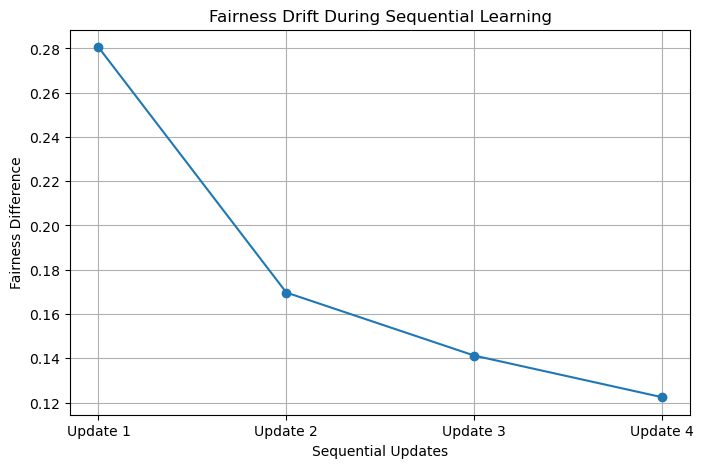

In [21]:
# =====================================================
# FAIRNESS DRIFT GRAPH
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    update_labels,
    fairness_scores,
    marker="o"
)

plt.title(
    "Fairness Drift During Sequential Learning"
)

plt.xlabel(
    "Sequential Updates"
)

plt.ylabel(
    "Fairness Difference"
)

plt.grid(True)

plt.show()

# Accuracy Evolution

This graph illustrates how predictive performance changes during sequential learning.

The relationship between accuracy and fairness can then be analysed.

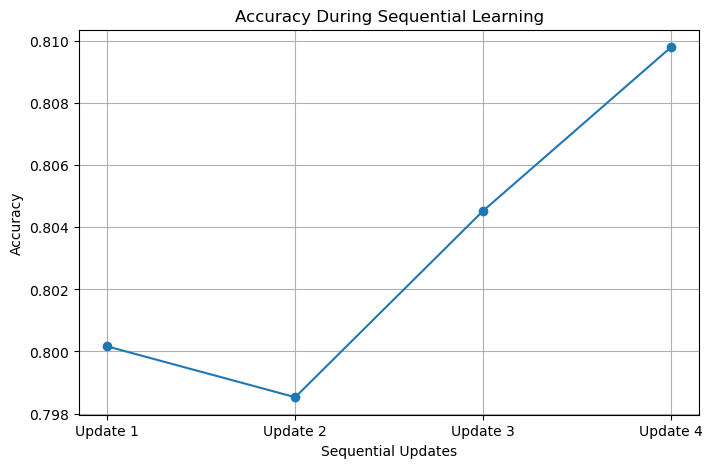

In [22]:
# =====================================================
# ACCURACY EVOLUTION GRAPH
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    update_labels,
    accuracy_scores,
    marker="o"
)

plt.title(
    "Accuracy During Sequential Learning"
)

plt.xlabel(
    "Sequential Updates"
)

plt.ylabel(
    "Accuracy"
)

plt.grid(True)

plt.show()

# Experiment 2: Fairness Under Dynamic Deployment Conditions

This experiment simulates a dynamic deployment environment.

Unlike sequential learning, where the model receives new data over time, a dynamic deployment environment changes the demographic composition of incoming data.

The goal is to observe whether fairness remains stable when population distributions change after deployment.

In [24]:
# ============================================
# Dynamic Deployment Environment Simulation
# ============================================

import numpy as np

print("Starting Dynamic Deployment Simulation...")

Starting Dynamic Deployment Simulation...


# Creating Dynamic Deployment Environments

In real-world deployment, demographic populations may change over time.

For example:

- A model may initially serve a balanced population.
- Later, more males than females may appear.
- Later, the population distribution may shift again.

This experiment simulates demographic distribution shifts to evaluate whether fairness remains robust under changing deployment conditions.

In [25]:
# ============================================
# Create Dynamic Deployment Environments
# ============================================

# Environment 1 (Baseline)
env1 = data.sample(frac=0.25, random_state=1)

# Environment 2 (More males)
male_data = data[data["sex"] == 1]
female_data = data[data["sex"] == 0]

env2 = pd.concat([
    male_data.sample(n=8000, replace=True, random_state=2),
    female_data.sample(n=2000, replace=True, random_state=2)
])

# Environment 3 (More females)
env3 = pd.concat([
    male_data.sample(n=2000, replace=True, random_state=3),
    female_data.sample(n=8000, replace=True, random_state=3)
])

# Environment 4 (Random shift)
env4 = data.sample(frac=0.25, random_state=4)

environments = [env1, env2, env3, env4]

print("Dynamic environments created successfully.")

Dynamic environments created successfully.


# Evaluating Fairness Robustness Under Distribution Shift

This experiment evaluates whether fairness remains stable when the demographic composition of deployed data changes.

The model is trained once and then tested across multiple deployment environments with different population distributions.

The objective is to determine whether fairness robustness is maintained under dynamic deployment conditions.

In [26]:
# ============================================
# Fairness Robustness Under Dynamic Deployment
# ============================================

from sklearn.metrics import accuracy_score

dynamic_fairness = []
dynamic_accuracy = []

for i, env in enumerate(environments):

    print(f"\nTesting Environment {i+1}")

    X_env = env.drop("income", axis=1)
    y_env = env["income"]

    predictions = model.predict(X_env)

    # Accuracy
    acc = accuracy_score(y_env, predictions)

    # Fairness Difference
    male_rate = predictions[env["sex"] == 1].mean()
    female_rate = predictions[env["sex"] == 0].mean()

    fairness_gap = abs(male_rate - female_rate)

    dynamic_accuracy.append(acc)
    dynamic_fairness.append(fairness_gap)

    print("Accuracy:", round(acc, 4))
    print("Fairness Difference:", round(fairness_gap, 4))


Testing Environment 1
Accuracy: 0.8111
Fairness Difference: 0.1284

Testing Environment 2
Accuracy: 0.795
Fairness Difference: 0.1151

Testing Environment 3
Accuracy: 0.8604
Fairness Difference: 0.107

Testing Environment 4
Accuracy: 0.7985
Fairness Difference: 0.1151


# Fairness Robustness Across Dynamic Deployment Environments

The following graph illustrates how fairness changes when the model is exposed to different deployment environments with varying demographic distributions.

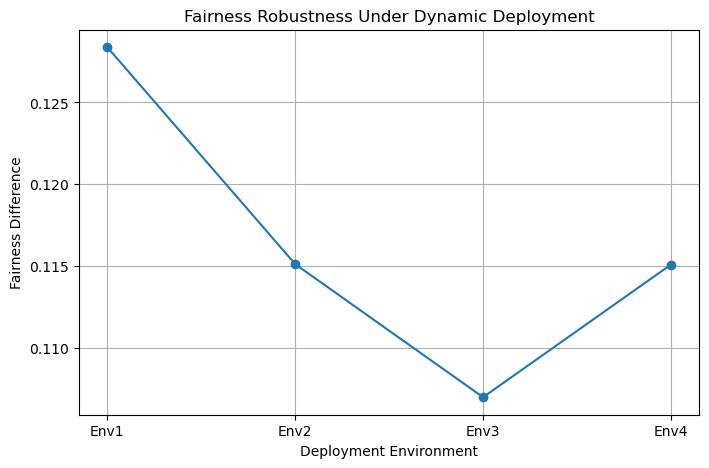

In [27]:
# ============================================
# Plot Fairness Robustness
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    ["Env1","Env2","Env3","Env4"],
    dynamic_fairness,
    marker="o"
)

plt.title("Fairness Robustness Under Dynamic Deployment")
plt.xlabel("Deployment Environment")
plt.ylabel("Fairness Difference")
plt.grid(True)

plt.show()

# Summary of Experimental Findings

| Experiment | Key Observation |
|------------|----------------|
| Sequential Learning | Fairness changed during repeated model updates |
| Dynamic Deployment | Fairness changed under distribution shift |
| Overall Conclusion | Fairness is dynamic and requires continual monitoring |